Raw shape: (6123270, 6)

✅ User features shape: (46674, 8)
   user_id  acc_mean  acc_std    rt_mean     rt_std  hint_mean  skills_tried  \
0    21421     0.700    0.483  12196.500   7792.087       0.50            10   
1    24586     1.000    0.000  11717.500   6125.381       0.00            10   
2    26046     0.786    0.426  15353.786   7965.303       0.00            14   
3    26787     0.000      NaN  11612.000        NaN       0.00             1   
4    52535     0.778    0.419  14762.651  18184.500       0.19            63   

   session_len  
0    12196.500  
1    11717.500  
2    15353.786  
3    11612.000  
4    14762.651  
✅ SAVED assist_user_stats.csv


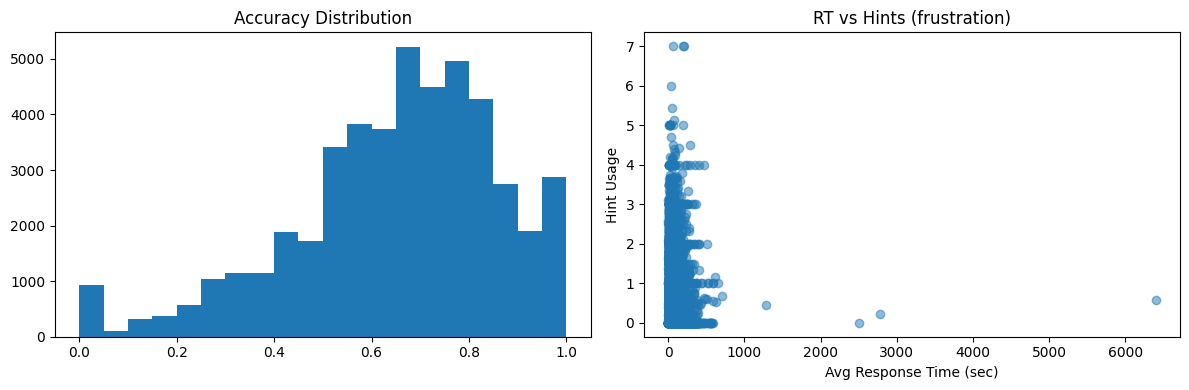

✅ PERFORMANCE READY → Cognitive Risk next!


In [3]:
# === CELL 1: Load ASSISTments ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('default')

base = Path("..") / "data" / "raw"
assist = pd.read_csv(base / "ASSISTments_Data_Set_2012-2013.csv")

# Keep only needed columns + clean
assist = assist[['user_id', 'correct', 'ms_first_response',
                 'hint_count', 'problem_id', 'overlap_time']]
assist = assist.dropna(subset=['user_id', 'correct', 'ms_first_response'])

print("Raw shape:", assist.shape)

# === CELL 2: User performance features ===
def user_features(df):
    """Performance stream → behavioral features"""
    user_stats = df.groupby('user_id').agg({
        'correct': ['mean', 'std'],              # accuracy + variability
        'ms_first_response': ['mean', 'std'],    # response time
        'hint_count': 'mean',                    # frustration proxy
        'problem_id': 'nunique',                 # skills attempted
        'overlap_time': 'mean'                   # session length proxy
    }).round(3)

    user_stats.columns = [
        'acc_mean', 'acc_std',
        'rt_mean', 'rt_std',
        'hint_mean', 'skills_tried', 'session_len'
    ]
    return user_stats.reset_index()

perf_feats = user_features(assist)
print("\n✅ User features shape:", perf_feats.shape)
print(perf_feats.head())

# === CELL 3: Save processed ===
perf_feats.to_csv("../data/processed/assist_user_stats.csv", index=False)
print("✅ SAVED assist_user_stats.csv")

# === CELL 4: Visualize ===
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(perf_feats['acc_mean'], bins=20)
plt.title("Accuracy Distribution")

plt.subplot(1,2,2)
plt.scatter(perf_feats['rt_mean']/1000, perf_feats['hint_mean'], alpha=0.5)
plt.xlabel("Avg Response Time (sec)")
plt.ylabel("Hint Usage")
plt.title("RT vs Hints (frustration)")

plt.tight_layout()
plt.savefig("../results/figures/perf_feats.png")
plt.show()

print("✅ PERFORMANCE READY → Cognitive Risk next!")
